In [1]:
## Ensemble Learning is a machine learning approach that combines multiple weak learners to construct a more powerful prediction model.
## 3 types of Ensemble Methods
#1.Bagging :Ask 10 doctors independently, then average their answers.
#2. Boosting: Doctor 1 gives diagnosis. Doctor 2 reviews mistakes. Doctor 3 reviews remaining mistakes.
#3.Stacking : Ask a surgeon, a radiologist, and a GP. Then have a chief doctor decide who to trust.


In [18]:
#1.Bagging == Bootstrap aggregating(Randomly sample your data with replacement ).
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, ValidationCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
X, y = make_classification(
    n_samples = 500,
    n_features= 10,
    n_informative= 8,
    n_redundant= 2,
    random_state= 42,
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)


In [4]:
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9
0,1.899136,-0.504262,-1.865578,2.383487,0.734764,1.105161,-2.229556,1.403973,-1.060674,-0.500870
1,2.467613,-3.406937,1.849073,1.470365,1.711802,-0.961105,-1.671268,0.039823,-1.258042,-1.077519
2,2.644711,0.889965,5.222994,-1.878677,-1.520034,3.023644,-0.447476,0.413821,-0.901039,-1.570579
3,5.766245,-0.878676,-1.187759,9.121980,0.398671,-2.391950,-4.457044,-1.512490,0.718755,0.302933
4,-0.689113,-1.485219,1.607958,-1.439935,0.853096,0.712017,-0.154815,0.309090,-1.785011,1.235665


In [5]:
## single Tree
single_tree = DecisionTreeClassifier(random_state= 42)
single_tree.fit(X_train, y_train)
single_pred = single_tree.predict(X_test)
single_tree_acc = accuracy_score(y_test, single_pred)
single_tree_acc

0.91

In [16]:
## Bagging ensemble
bagging = BaggingClassifier(
    estimator= DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf= 10,
        min_samples_split= 20,
        max_features=0.5
        ),
    n_estimators= 200, ## 50 trees
    random_state= 42
)
bagging.fit(X_train, y_train)
bagging_pred = bagging.predict(X_test)
bagging_acc = accuracy_score(y_test, bagging_pred)
bagging_acc

0.85

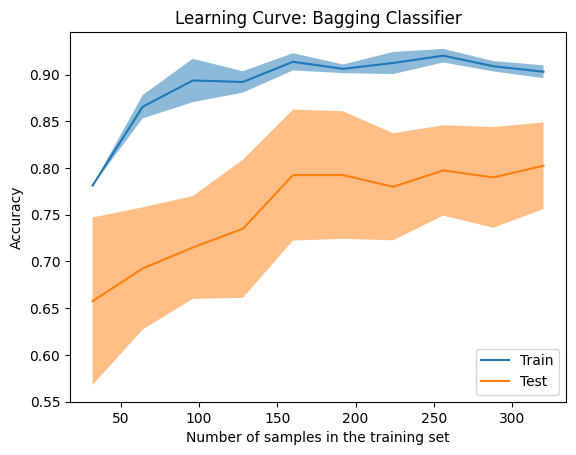

Train Accuracy: 0.9100
Test Accuracy: 0.8500
Gap (Overfitting indicator): 0.0600


In [17]:
from sklearn.model_selection import LearningCurveDisplay
import matplotlib.pyplot as plt

# Your trained bagging model
LearningCurveDisplay.from_estimator(
    bagging,  
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)
plt.title('Learning Curve: Bagging Classifier')
plt.show()

# Also print the final gap
train_score = bagging.score(X_train, y_train)
test_score = bagging.score(X_test, y_test)
print(f"Train Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")
print(f"Gap (Overfitting indicator): {train_score - test_score:.4f}")

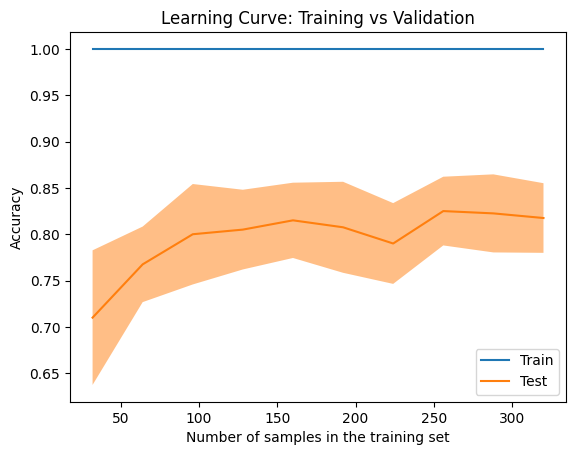

In [10]:
from sklearn.model_selection import LearningCurveDisplay

LearningCurveDisplay.from_estimator(
    BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=None), n_estimators=200, random_state=42),
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)
plt.title('Learning Curve: Training vs Validation')
plt.show()

In [20]:
## let's try Random Forest
rf = RandomForestClassifier(
    n_estimators= 200,
    max_depth= 5, 
    min_samples_split= 20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state= 42
)
rf.fit(X_train, y_train)
train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)

print(f"Random Forest:")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Gap: {train_acc - test_acc:.4f}")


Random Forest:
Train Accuracy: 0.9100
Test Accuracy: 0.8300
Gap: 0.0800


## Boosting

In [22]:
## AdaBoost
X, y = make_classification(
    n_samples= 500,
    n_features= 10, 
    n_informative= 8,
    n_redundant= 2,
    random_state= 42
)
# Convert labels to -1 and 1 (standard for AdaBoost)
y = np.where(y == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size= 0.3, random_state= 32)

In [37]:
from sklearn.ensemble import AdaBoostClassifier


ada = AdaBoostClassifier(
    estimator= DecisionTreeClassifier(max_depth= 5),
    n_estimators= 200,
    learning_rate= 1.0
)
ada.fit(X_train, y_train)
predictions = ada.predict(X_test)
accuracy_score(predictions, y_test)

0.8933333333333333

<Axes: xlabel='feature'>

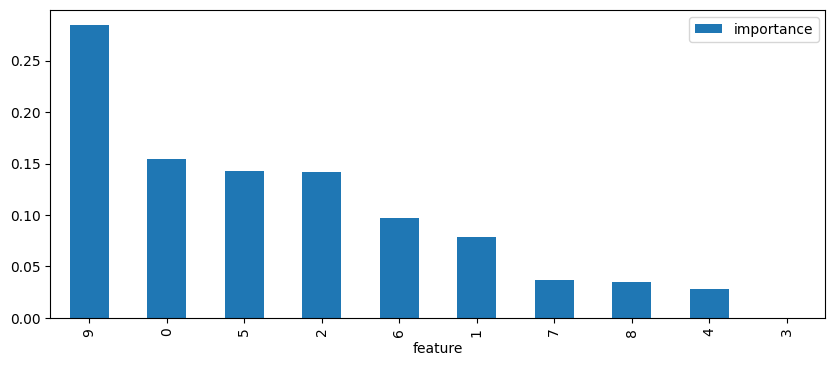

In [26]:
import pandas as pd

# Get feature importance
importance = pd.DataFrame({
    'feature': range(X.shape[1]),
    'importance': ada.feature_importances_
}).sort_values('importance', ascending=False)

# Plot
importance.plot(x='feature', y='importance', kind='bar', figsize=(10, 4))

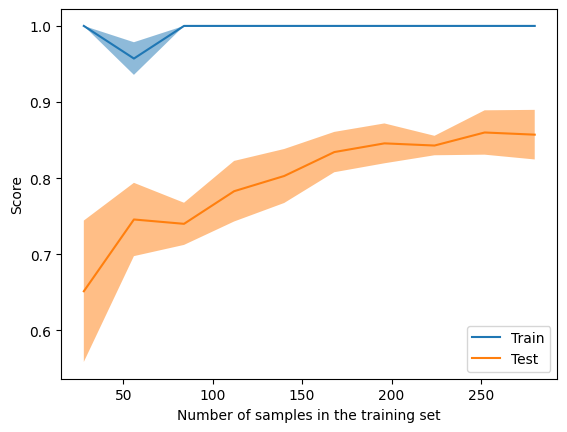

In [38]:
from sklearn.model_selection import LearningCurveDisplay

LearningCurveDisplay.from_estimator(ada, X_train, y_train, train_sizes=np.linspace(0.1, 1.0, 10))

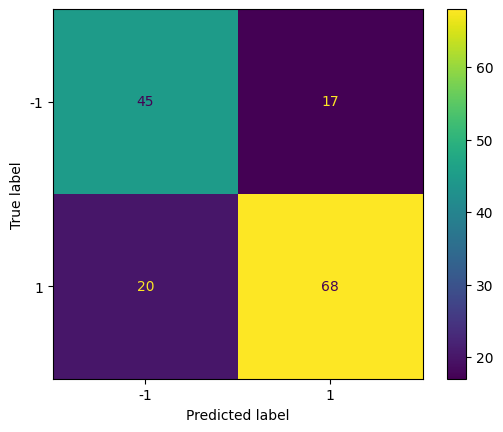

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(ada, X_test, y_test)